In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import missingno as msno
import seaborn as sns
import matplotlib.colors as mcolors

In [ ]:
# Lendo os arquivos do fbref


df_defensive_stats = pd.read_excel('DEFENSE_BRASILEIRAO.xlsx')
df_miscellaneous_stats = pd.read_excel('MISC_BRASILEIRAO.xlsx')
df_stats_standard = pd.read_excel('STATS_STANDARD_BRASILEIRAO.xlsx')
df_adv_goalkeeping_teamsbr24 = pd.read_excel('SQUAD_ADVANCED_GOALKEEPING_BR24.xlsx')
df_possession_teamsbr24 = pd.read_excel('SQUAD_POSSESSION_BR24.xlsx')


In [ ]:
# Criando cópia do dataframe
df_defensive_stats_copy = df_defensive_stats.copy()
df_miscellaneous_stats_copy = df_miscellaneous_stats.copy()
df_stats_standard_copy = df_stats_standard.copy()
df_adv_goalkeeping_teamsbr24_copy = df_adv_goalkeeping_teamsbr24.copy()
df_possession_teamsbr24_copy = df_possession_teamsbr24.copy()


In [ ]:
df_defensive_stats.head(35)

,Tackles,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Challenges,Unnamed: 6,Unnamed: 7,Unnamed: 8,Blocks,...,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25,Unnamed: 26,Unnamed: 27,Unnamed: 28
0,Rk,Player,Nation,Pos,Squad,Age,Born,90s,Tkl,TklW,...,Pass,Int,Tkl+Int,Clr,Err,Player_key_FBREF,AGE_Wyscout,Pos_Wyscout,Match_Wyscout,Pos_FINAL
1,1,Abner,br BRA,RCB,Juventude,20,2004,14.6,19,11,...,10,18,37,98,2,abner,20,RCB,Zagueiro Wyscout,RCB
2,2,Nicolás Acevedo,uy URU,MF,Bahia,25,1999,18.8,58,40,...,26,31,89,23,0,nicolas acevedo,25,NaN,Não listado,MF
3,3,Luciano Acosta,ar ARG,MF,Fluminense,30,1994,13.3,19,14,...,16,0,19,7,0,luciano acosta,30,NaN,Não listado,MF
4,4,Adriel,br BRA,MF,Sport Recife,18,2006,1.6,4,3,...,2,1,5,4,0,adriel,18,NaN,Não listado,MF
5,5,Adson,br BRA,"FW,MF",Vasco da Gama,24,2000,2.3,6,4,...,2,0,6,5,0,adson,24,NaN,Não listado,"FW,MF"
6,6,Braian Aguirre,ar ARG,DF,Internacional,24,2000,26.5,69,43,...,18,31,100,98,3,braian aguirre,24,NaN,Não listado,DF
7,7,Carlos Alberto,br BRA,"FW,MF",Sport Recife,22,2002,3.7,4,3,...,2,9,13,7,0,carlos alberto,22,NaN,Não listado,"FW,MF"
8,8,Yuri Alberto,br BRA,FW,Corinthians,23,2001,22.3,12,7,...,5,4,16,17,2,yuri alberto,23,NaN,Não listado,FW
9,9,José Aldo,br BRA,MF,Mirassol,26,1998,15.2,35,24,...,18,27,62,28,1,jose aldo,26,NaN,Não listado,MF


In [ ]:
df_defensive_stats_copy.head(35)

,Tackles,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Challenges,Unnamed: 6,Unnamed: 7,Unnamed: 8,Blocks,...,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25,Unnamed: 26,Unnamed: 27,Unnamed: 28
0,Rk,Player,Nation,Pos,Squad,Age,Born,90s,Tkl,TklW,...,Pass,Int,Tkl+Int,Clr,Err,Player_key_FBREF,AGE_Wyscout,Pos_Wyscout,Match_Wyscout,Pos_FINAL
1,1,Abner,br BRA,RCB,Juventude,20,2004,14.6,19,11,...,10,18,37,98,2,abner,20,RCB,Zagueiro Wyscout,RCB
2,2,Nicolás Acevedo,uy URU,MF,Bahia,25,1999,18.8,58,40,...,26,31,89,23,0,nicolas acevedo,25,NaN,Não listado,MF
3,3,Luciano Acosta,ar ARG,MF,Fluminense,30,1994,13.3,19,14,...,16,0,19,7,0,luciano acosta,30,NaN,Não listado,MF
4,4,Adriel,br BRA,MF,Sport Recife,18,2006,1.6,4,3,...,2,1,5,4,0,adriel,18,NaN,Não listado,MF
5,5,Adson,br BRA,"FW,MF",Vasco da Gama,24,2000,2.3,6,4,...,2,0,6,5,0,adson,24,NaN,Não listado,"FW,MF"
6,6,Braian Aguirre,ar ARG,DF,Internacional,24,2000,26.5,69,43,...,18,31,100,98,3,braian aguirre,24,NaN,Não listado,DF
7,7,Carlos Alberto,br BRA,"FW,MF",Sport Recife,22,2002,3.7,4,3,...,2,9,13,7,0,carlos alberto,22,NaN,Não listado,"FW,MF"
8,8,Yuri Alberto,br BRA,FW,Corinthians,23,2001,22.3,12,7,...,5,4,16,17,2,yuri alberto,23,NaN,Não listado,FW
9,9,José Aldo,br BRA,MF,Mirassol,26,1998,15.2,35,24,...,18,27,62,28,1,jose aldo,26,NaN,Não listado,MF


In [ ]:
# Ajustando os nomes das colunas
df_defensive_stats_copy.columns = df_defensive_stats_copy.iloc[0]
df_miscellaneous_stats_copy.columns = df_miscellaneous_stats_copy.iloc[0]
df_stats_standard_copy.columns = df_stats_standard_copy.iloc[0]
df_adv_goalkeeping_teamsbr24_copy.columns = df_adv_goalkeeping_teamsbr24_copy.iloc[0]
df_possession_teamsbr24_copy.columns = df_possession_teamsbr24_copy.iloc[0]
df_defensive_stats_copy

,Rk,Player,Nation,Pos,Squad,Age,Born,90s,Tkl,TklW,...,Pass,Int,Tkl+Int,Clr,Err,Player_key_FBREF,AGE_Wyscout,Pos_Wyscout,Match_Wyscout,Pos_FINAL
0,Rk,Player,Nation,Pos,Squad,Age,Born,90s,Tkl,TklW,...,Pass,Int,Tkl+Int,Clr,Err,Player_key_FBREF,AGE_Wyscout,Pos_Wyscout,Match_Wyscout,Pos_FINAL
1,1,Abner,br BRA,RCB,Juventude,20,2004,14.6,19,11,...,10,18,37,98,2,abner,20,RCB,Zagueiro Wyscout,RCB
2,2,Nicolás Acevedo,uy URU,MF,Bahia,25,1999,18.8,58,40,...,26,31,89,23,0,nicolas acevedo,25,NaN,Não listado,MF
3,3,Luciano Acosta,ar ARG,MF,Fluminense,30,1994,13.3,19,14,...,16,0,19,7,0,luciano acosta,30,NaN,Não listado,MF
4,4,Adriel,br BRA,MF,Sport Recife,18,2006,1.6,4,3,...,2,1,5,4,0,adriel,18,NaN,Não listado,MF
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
787,757,Yago,br BRA,MF,Mirassol,29,1995,7,18,7,...,10,6,24,6,1,yago,29,NaN,Não listado,MF
788,758,Yago,br BRA,MF,Internacional,17,2007,0.8,1,1,...,3,0,1,2,0,yago,17,NaN,Não listado,MF
789,759,Young,br BRA,GK,São Paulo,22,2002,3,0,0,...,0,0,0,1,1,young,22,NaN,Não listado,GK
790,760,Vinícius Zanocelo,br BRA,MF,Ceará,24,2001,12.1,25,17,...,7,16,41,27,0,vinicius zanocelo,24,NaN,Não listado,MF


In [ ]:
# Excluindo a primeira linha
df_defensive_stats_copy = df_defensive_stats_copy.iloc[1:]
df_miscellaneous_stats_copy = df_miscellaneous_stats_copy.iloc[1:]
df_stats_standard_copy = df_stats_standard_copy.iloc[1:]
df_adv_goalkeeping_teamsbr24_copy = df_adv_goalkeeping_teamsbr24_copy.iloc[1:]
df_possession_teamsbr24_copy = df_possession_teamsbr24_copy.iloc[1:]

In [ ]:
  # Excluindo linhas
  df_defensive_stats_copy = df_defensive_stats_copy.drop(columns=['Rk'], errors='ignore')
  df_defensive_stats_copy = df_defensive_stats_copy.drop_duplicates()
  df_defensive_stats_copy = df_defensive_stats_copy[
    df_defensive_stats_copy['Player'] != 'Player'
]
  df_defensive_stats_copy.head(35)

,Player,Nation,Pos,Squad,Age,Born,90s,Tkl,TklW,Def 3rd,...,Pass,Int,Tkl+Int,Clr,Err,Player_key_FBREF,AGE_Wyscout,Pos_Wyscout,Match_Wyscout,Pos_FINAL
1,Abner,br BRA,RCB,Juventude,20,2004,14.6,19,11,13,...,10,18,37,98,2,abner,20,RCB,Zagueiro Wyscout,RCB
2,Nicolás Acevedo,uy URU,MF,Bahia,25,1999,18.8,58,40,22,...,26,31,89,23,0,nicolas acevedo,25,NaN,Não listado,MF
3,Luciano Acosta,ar ARG,MF,Fluminense,30,1994,13.3,19,14,5,...,16,0,19,7,0,luciano acosta,30,NaN,Não listado,MF
4,Adriel,br BRA,MF,Sport Recife,18,2006,1.6,4,3,2,...,2,1,5,4,0,adriel,18,NaN,Não listado,MF
5,Adson,br BRA,"FW,MF",Vasco da Gama,24,2000,2.3,6,4,4,...,2,0,6,5,0,adson,24,NaN,Não listado,"FW,MF"
6,Braian Aguirre,ar ARG,DF,Internacional,24,2000,26.5,69,43,29,...,18,31,100,98,3,braian aguirre,24,NaN,Não listado,DF
7,Carlos Alberto,br BRA,"FW,MF",Sport Recife,22,2002,3.7,4,3,2,...,2,9,13,7,0,carlos alberto,22,NaN,Não listado,"FW,MF"
8,Yuri Alberto,br BRA,FW,Corinthians,23,2001,22.3,12,7,2,...,5,4,16,17,2,yuri alberto,23,NaN,Não listado,FW
9,José Aldo,br BRA,MF,Mirassol,26,1998,15.2,35,24,19,...,18,27,62,28,1,jose aldo,26,NaN,Não listado,MF
10,Alesson,br BRA,FW,Mirassol,25,1999,16.2,26,13,6,...,23,6,32,10,0,alesson,25,NaN,Não listado,FW


In [ ]:
  df_defensive_stats_copy.tail(35)

,Player,Nation,Pos,Squad,Age,Born,90s,Tkl,TklW,Def 3rd,...,Pass,Int,Tkl+Int,Clr,Err,Player_key_FBREF,AGE_Wyscout,Pos_Wyscout,Match_Wyscout,Pos_FINAL
756,Matías Viña,uy URU,DF,Flamengo,27,1997,3.1,10,6,4,...,5,2,12,5,1,matias viña,27,NaN,Não listado,DF
757,Vinícius,br BRA,MF,Ceará,33,1991,6.3,4,2,0,...,2,0,4,1,0,vinicius,33,NaN,Não listado,MF
758,Alix Vinicius,br BRA,"RCB, LCB",RB Bragantino,25,1999,9.6,9,6,5,...,5,10,19,61,0,alix vinicius,25,"RCB, LCB",Zagueiro Wyscout,"RCB, LCB"
759,Carlos Vinícius,br BRA,FW,Grêmio,29,1995,10.5,2,2,0,...,2,0,2,9,0,carlos vinicius,29,NaN,Não listado,FW
760,Vitão,br BRA,"RCB, LCB",Internacional,24,2000,30.2,31,21,21,...,13,22,53,146,1,vitao,24,"RCB, LCB",Zagueiro Wyscout,"RCB, LCB"
761,Vitinho,br BRA,"FW,MF",Internacional,25,1999,18.7,28,17,11,...,19,15,43,24,0,vitinho,25,NaN,Não listado,"FW,MF"
762,Vitinho,br BRA,"FW,MF",Corinthians,31,1993,5.3,12,8,6,...,6,2,14,0,0,vitinho,31,NaN,Não listado,"FW,MF"
763,Vitinho,br BRA,DF,Botafogo (RJ),25,1999,31.5,69,40,47,...,24,26,95,87,1,vitinho,25,NaN,Não listado,DF
764,Rayan Vitor,br BRA,FW,Vasco da Gama,18,2006,31.5,30,15,10,...,19,14,44,49,0,rayan vitor,18,NaN,Não listado,FW
765,Tiago Volpi,br BRA,GK,Grêmio,34,1990,32,0,0,0,...,0,0,0,8,2,tiago volpi,34,NaN,Não listado,GK


In [ ]:
df_defensive_stats_copy.columns.to_list()

['Player',
 'Nation',
 'Pos',
 'Squad',
 'Age',
 'Born',
 '90s',
 'Tkl',
 'TklW',
 'Def 3rd',
 'Mid 3rd',
 'Att 3rd',
 'Tkl',
 'Att',
 'Tkl%',
 'Lost',
 'Blocks',
 'Sh',
 'Pass',
 'Int',
 'Tkl+Int',
 'Clr',
 'Err',
 'Player_key_FBREF',
 'AGE_Wyscout',
 'Pos_Wyscout',
 'Match_Wyscout',
 'Pos_FINAL']

In [ ]:
#RENOMEANDO COLUNAS

df_adv_goalkeeping_teamsbr24_copy = df_adv_goalkeeping_teamsbr24_copy.rename(columns={
    'Opp': 'Crosses Faced',
})
df_adv_goalkeeping_teamsbr24_copy.columns.to_list()

['Squad',
 '# Pl',
 '90s',
 'GA',
 'PKA',
 'FK',
 'CK',
 'OG',
 'PSxG',
 'PSxG/SoT',
 'PSxG+/-',
 '/90',
 'Cmp',
 'Att',
 'Cmp%',
 'Att (GK)',
 'Thr',
 'Launch%',
 'AvgLen',
 'Att',
 'Launch%',
 'AvgLen',
 'Crosses Faced',
 'Stp',
 'Stp%',
 '#OPA',
 '#OPA/90',
 'AvgDist']

In [ ]:
df_defensive_stats_copy

,Player,Nation,Pos,Squad,Age,Born,90s,Tkl,TklW,Def 3rd,...,Pass,Int,Tkl+Int,Clr,Err,Player_key_FBREF,AGE_Wyscout,Pos_Wyscout,Match_Wyscout,Pos_FINAL
1,Abner,br BRA,RCB,Juventude,20,2004,14.6,19,11,13,...,10,18,37,98,2,abner,20,RCB,Zagueiro Wyscout,RCB
2,Nicolás Acevedo,uy URU,MF,Bahia,25,1999,18.8,58,40,22,...,26,31,89,23,0,nicolas acevedo,25,NaN,Não listado,MF
3,Luciano Acosta,ar ARG,MF,Fluminense,30,1994,13.3,19,14,5,...,16,0,19,7,0,luciano acosta,30,NaN,Não listado,MF
4,Adriel,br BRA,MF,Sport Recife,18,2006,1.6,4,3,2,...,2,1,5,4,0,adriel,18,NaN,Não listado,MF
5,Adson,br BRA,"FW,MF",Vasco da Gama,24,2000,2.3,6,4,4,...,2,0,6,5,0,adson,24,NaN,Não listado,"FW,MF"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
787,Yago,br BRA,MF,Mirassol,29,1995,7,18,7,8,...,10,6,24,6,1,yago,29,NaN,Não listado,MF
788,Yago,br BRA,MF,Internacional,17,2007,0.8,1,1,0,...,3,0,1,2,0,yago,17,NaN,Não listado,MF
789,Young,br BRA,GK,São Paulo,22,2002,3,0,0,0,...,0,0,0,1,1,young,22,NaN,Não listado,GK
790,Vinícius Zanocelo,br BRA,MF,Ceará,24,2001,12.1,25,17,10,...,7,16,41,27,0,vinicius zanocelo,24,NaN,Não listado,MF


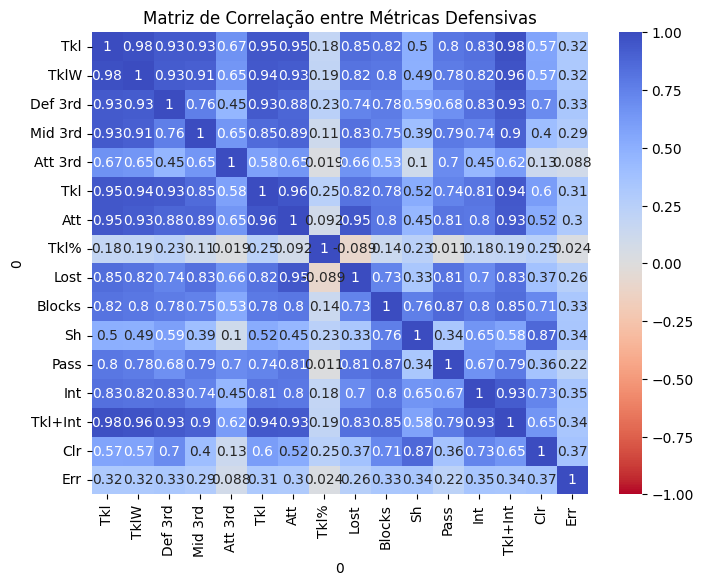

In [ ]:
# Matriz de correlação
def_stats_corr_matrix = df_defensive_stats_copy.drop(columns=['Player','Nation','Age','Born','Pos','90s','Squad', 'Player_key_FBREF', 'Pos_Wyscout', 'Match_Wyscout','Pos_FINAL', 'AGE_Wyscout' ]).corr()
def_stats_corr_matrix
# Heatmap de correlação
plt.figure(figsize=(8,6))
sns.heatmap(def_stats_corr_matrix, annot=True, cmap='coolwarm_r', vmin=-1, vmax=1)
plt.title('Matriz de Correlação entre Métricas Defensivas')
plt.show()

In [ ]:
# Selecionando apenas as colunas das métricas escolhidas

df_defensivo = df_defensive_stats_copy[['Player', 'Def 3rd', 'Sh', 'Clr','Squad','Int', 'Tkl%']].copy()
df_misc = df_miscellaneous_stats_copy[['Player', 'Won', 'Lost', 'Won%', 'Squad']].copy()
df_stats = df_stats_standard_copy[['Player', 'Min','Squad','Pos','Age']].copy()
df_crosses_faced =df_adv_goalkeeping_teamsbr24_copy[['Squad', 'Crosses Faced']].copy()
df_possession = df_possession_teamsbr24_copy[['Squad', 'Poss']].copy()



In [ ]:
set(df_defensive_stats_copy['Player']) == set(df_miscellaneous_stats_copy['Player'])


True

In [ ]:
set(df_defensivo['Player']) - set(df_misc['Player'])


set()

In [ ]:
# Criação de df_base com fitro de minutos e idade
# -----------------------------
df_base = (
    df_stats[(df_stats['Min'] >= 798) & (df_stats['Age'] <= 35)][['Player','Squad','Min','Pos','Age']] #USEI 798 AO INVES DE 800 PARA FILTRAR JHONATHAN JESUS
    .merge(df_defensivo, on=['Player','Squad'], how='left')
    .merge(df_misc, on=['Player','Squad'], how='left')
    .merge(df_possession[['Squad','Poss']], on='Squad', how='left')
    .merge(df_crosses_faced[['Squad','Crosses Faced']], on='Squad', how='left')
)

In [ ]:
# Converter colunas numéricas
cols_num = ['Def 3rd', 'Sh', 'Clr', 'Won', 'Lost', 'Won%', 'Crosses Faced', 'Min', 'Poss', 'Int', 'Tkl%']
df_base[cols_num] = df_base[cols_num].apply(pd.to_numeric, errors='coerce')

1. Construção das Métricas Base
Ajuste por tempo de jogo (por 90 minutos)

Todas as métricas defensivas são inicialmente padronizadas por 90 minutos, garantindo comparabilidade entre jogadores com diferentes volumes de minutos:

Ações defensivas no terço defensivo (Def 3rd)

Interceptações (Int)

Bloqueios de chute (Sh)

Cortes (Clr)

Duelos aéreos vencidos (Won)

Ajuste pelo contexto de posse

Para evitar penalizar jogadores de equipes dominantes, as métricas defensivas são ajustadas pela não-posse da equipe:

Esse ajuste garante que jogadores que defendem menos por contexto tático não sejam subavaliados.

Eficiência técnica

Duas métricas incorporam eficiência explícita:

def3rd_eff: ações defensivas no terço defensivo ajustadas pela taxa de sucesso em desarmes (Tkl%)

Aerial_Efficiency: percentual de duelos aéreos vencidos

2. Aerial Score — Impacto Aéreo Contextualizado

O Aerial_Score foi construído para capturar o impacto real do jogo aéreo, indo além do simples número de duelos vencidos.

Ele combina três elementos:

Volume individual por 90 (Won_per90)

Contexto coletivo, medido pelos cruzamentos sofridos pela equipe

Eficiência nos duelos (Won%)

Esse desenho permite comparar jogadores de equipes que sofrem volumes muito diferentes de bolas aéreas, evitando distorções estruturais.

In [ ]:
# Calculando métricas por 90 minutos e ajustando a metrica de duelos aerios vencidos com base nos crosses faced (cruzamentos sofridos pelo time)

# -----------------------------
df_base['Won_per90'] = df_base['Won'] / (df_base['Min']/90)
df_base['Crosses_Faced_per90'] = df_base['Crosses Faced'] / (3420/90)

df_base['Aerial_Context'] = df_base['Won_per90'] / df_base['Crosses_Faced_per90']
df_base['Aerial_Efficiency'] = df_base['Won%'] / 100
df_base['Aerial_Score'] = df_base['Aerial_Context'] * df_base['Aerial_Efficiency']

df_base['def3rd_p90'] = df_base['Def 3rd'] / (df_base['Min'] / 90)
df_base['block_sh_p90'] = df_base['Sh'] / (df_base['Min'] / 90)
df_base['Clr_p90'] = df_base['Clr'] / (df_base['Min'] / 90)
df_base['Int_p90'] = df_base['Int'] / (df_base['Min'] / 90)

In [ ]:
# Normalizando as métricas pela não posse
df_base['Nao_Poss'] = (100 - df_base['Poss']) / 100
df_base['def3rd_adj'] = df_base['def3rd_p90'] / df_base['Nao_Poss']
df_base['block_sh_adj'] = df_base['block_sh_p90'] / df_base['Nao_Poss']
df_base['Clr_adj'] = df_base['Clr_p90'] / df_base['Nao_Poss']
df_base['Int_adj'] = df_base['Int_p90'] / df_base['Nao_Poss']

df_base['Tkl_Eff'] = df_base['Tkl%'] / 100
df_base['def3rd_eff'] = df_base['def3rd_adj'] * df_base['Tkl_Eff']

3. Aerial Participation — Papel do Jogador Dentro da Equipe

Além do impacto absoluto, foi criada a métrica de Aerial Participation, que mede a participação relativa do jogador nos duelos aéreos defensivos do próprio time.

Para tornar comparações mais justas entre equipes, essa métrica é padronizada via Z-score dentro de cada equipe, gerando a variável:

Aerial_Participation_z

Essa abordagem identifica zagueiros que são protagonistas aéreos em suas equipes, independentemente do volume total do time.

In [ ]:
# Calcular Aerial Participation usando todos os defensores do time
# -----------------------------
df_team_def = df_base[df_base['Pos'].str.contains('CB|LCB|RCB|DF', regex=True)].copy()
team_aerial = df_team_def.groupby('Squad')[['Won']].sum().rename(columns={'Won':'Team_Won'})
df_team_def = df_team_def.merge(team_aerial, on='Squad', how='left')
df_team_def['Aerial_Participation'] = df_team_def['Won'] / df_team_def['Team_Won']

from scipy.stats import zscore
df_team_def['Aerial_Participation_z'] = df_team_def.groupby('Squad')['Aerial_Participation'].transform(zscore)

In [ ]:
# Filtrar apenas zagueiros para ranking e merge com Aerial Participation
# -----------------------------
df_zagueiros = df_base[df_base['Pos'].str.contains('CB|LCB|RCB', regex=True)].copy()
participation_z = df_team_def[['Player','Squad','Aerial_Participation','Aerial_Participation_z']]
df_zagueiros = df_zagueiros.merge(participation_z, on=['Player','Squad'], how='left')

4. Normalização das Métricas (Min-Max Scaling)

As métricas finais utilizadas no score são normalizadas utilizando Min-Max Scaler, transformando todas para o intervalo [0,1]:

Essa etapa garante que métricas em escalas diferentes contribuam de forma equilibrada para o score final.

In [ ]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
cols_norm = ['Aerial_Score','def3rd_eff','block_sh_adj','Clr_adj','Int_adj']
df_zagueiros[[col + '_final' for col in cols_norm]] = scaler.fit_transform(df_zagueiros[cols_norm])

5. Lógica da Distribuição dos Pesos

def3rd_eff (35%)
Principal indicador do impacto defensivo direto, pois combina volume, contexto e eficiência na zona mais crítica do campo.

Interceptações ajustadas (20%)
Capturam leitura de jogo e capacidade de antecipação, fundamentais para evitar progressões perigosas.

Bloqueios e cortes (15% cada)
Representam ações reativas de contenção de perigo imediato, importantes, mas parcialmente correlacionadas.

Aerial Score (15%)
Considera o impacto aéreo absoluto, já ajustado por contexto e eficiência, evitando redundância com cortes.

In [ ]:
df_zagueiros['DefScore_base'] = (
    0.15 * df_zagueiros['Aerial_Score_final'] +
    0.35 * df_zagueiros['def3rd_eff_final'] +
    0.20 * df_zagueiros['Int_adj_final'] +
    0.15 * df_zagueiros['block_sh_adj_final'] +
    0.15 * df_zagueiros['Clr_adj_final']
)

6. Ajuste Final por Protagonismo Aéreo

O DefScore_final incorpora um ajuste multiplicativo baseado no papel do jogador no jogo aéreo da equipe:

Esse ajuste premia jogadores que, além de eficientes, assumem maior responsabilidade aérea dentro da estrutura defensiva do time.

In [ ]:
# Calcular DefScore final
# -----------------------------
df_zagueiros['DefScore_final'] = df_zagueiros['DefScore_base'] * (1 + 0.1 * df_zagueiros['Aerial_Participation_z'])

In [ ]:
# Ranking final
# -----------------------------
df_ranking_def = df_zagueiros[['Player','Age','Squad','Pos','DefScore_final',
                              'Aerial_Score_final','def3rd_eff_final','Int_adj_final','block_sh_adj_final','Clr_adj_final',
                              'Aerial_Participation','Aerial_Participation_z']].sort_values('DefScore_final', ascending=False).reset_index(drop=True)

df_ranking_def.head(50)

,Player,Age,Squad,Pos,DefScore_final,Aerial_Score_final,def3rd_eff_final,Int_adj_final,block_sh_adj_final,Clr_adj_final,Aerial_Participation,Aerial_Participation_z
0,Vitor Hugo,33,Atlético Mineiro,"CB, LCB",0.782551,0.927201,0.602887,0.525953,0.497128,0.820730,0.218750,1.984674
1,Alexander Barboza,29,Botafogo (RJ),"LCB, RCB",0.761804,0.727312,0.796278,0.248078,0.325404,0.888591,0.299578,2.296895
2,João Victor,26,Vasco da Gama,RCB,0.728601,0.692489,0.849252,0.121737,0.383544,0.818919,0.195455,2.026533
3,Gustavo Gómez,31,Palmeiras,"RCB, CB",0.704879,0.849988,0.529065,0.471628,0.513788,0.660393,0.295918,2.087981
4,Lyanco,27,Atlético Mineiro,"RCB, CB",0.704714,0.510238,0.677943,1.000000,0.467033,0.615634,0.118056,0.421437
5,Victor Gabriel,20,Internacional,"LCB, LB",0.691903,0.822273,0.581822,0.500287,0.521491,1.000000,0.220930,0.559218
6,Ignácio,28,Fluminense,RCB,0.631589,0.427115,0.781588,0.386020,0.476289,0.991282,0.160920,-0.053124
7,Gustavo Henrique,31,Corinthians,"LCB, CB",0.621756,1.000000,0.329210,0.214680,0.597068,0.713285,0.279851,2.319015
8,Rodrigo Sam,29,Juventude,"CB, LCB, RCB",0.605960,0.669911,0.573686,0.488358,0.202631,0.625850,0.191489,1.581353
9,EDU,24,Vitória,"RCB, RB",0.573815,0.237422,1.000000,0.170644,0.200055,0.836808,0.109244,-0.025324


In [ ]:
df_base.loc[df_base['Player'] == 'João Victor',
['Def 3rd', 'Min', 'def3rd_p90']]

,Def 3rd,Min,def3rd_p90
342,13,3059,0.382478
343,23,1435,1.442509


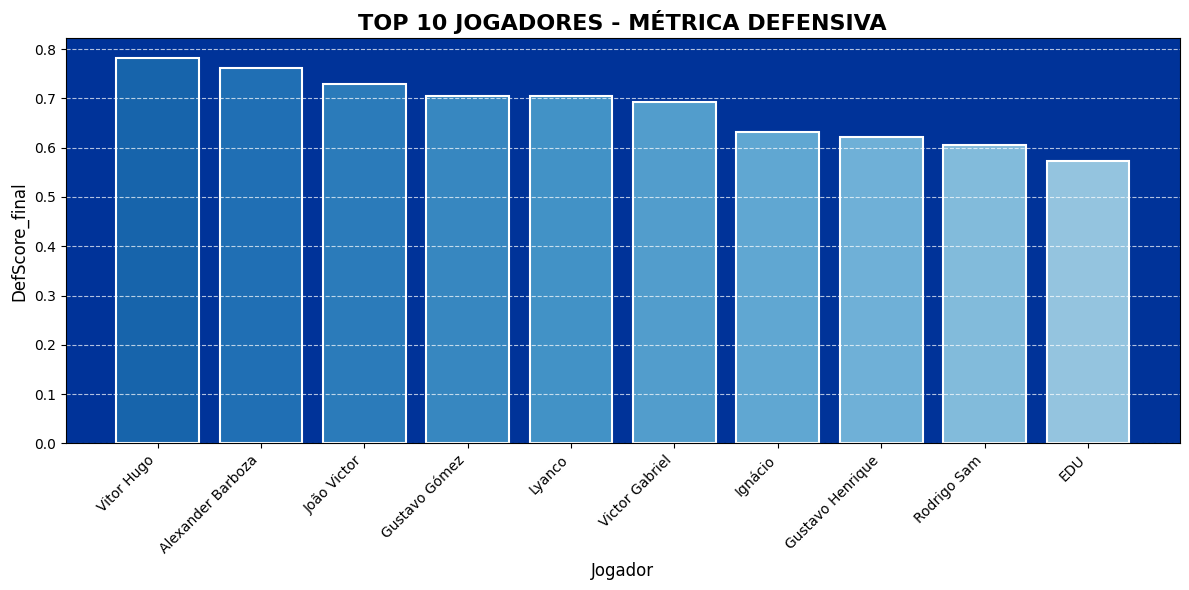

In [ ]:
# RANKING TOP10JOGADORES

# Selecionar top 10
top10 = df_ranking_def.sort_values('DefScore_final', ascending=False).head(10)

# Gradiente azul invertido: jogadores melhores mais escuros
colors = plt.cm.Blues(np.linspace(0.8, 0.4, len(top10)))  # invertido

plt.figure(figsize=(12,6))
bars = plt.bar(top10['Player'], top10['DefScore_final'], color=colors, edgecolor='white', linewidth=1.5)

# Títulos e labels
plt.title('TOP 10 JOGADORES - MÉTRICA DEFENSIVA', fontsize=16, fontweight='bold')
plt.xlabel('Jogador', fontsize=12)
plt.ylabel('DefScore_final', fontsize=12)

# Tornar os nomes legíveis
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)

# Fundo branco
plt.gca().set_facecolor('#003399')  # azul Cruzeiro
plt.grid(axis='y', linestyle='--', alpha=0.7, color='white')  # linhas horizontais brancas para contraste

plt.tight_layout()
plt.show()

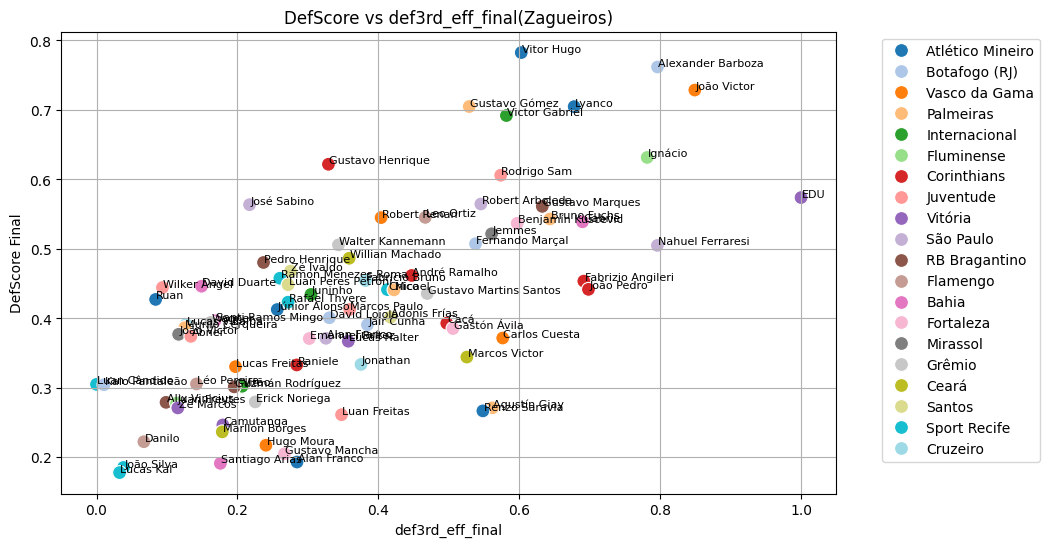

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go

# -----------------------------
# 1️⃣ Scatter plot DefScore vs def3rd_eff_final
# -----------------------------
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=df_ranking_def,
    x='def3rd_eff_final',
    y='DefScore_final',
    hue='Squad',
    s=100,
    palette='tab20'
)
for i, row in df_ranking_def.iterrows():
    plt.text(row['def3rd_eff_final']+0.001, row['DefScore_final']+0.001, row['Player'], fontsize=8)

plt.title("DefScore vs def3rd_eff_final(Zagueiros)")
plt.xlabel("def3rd_eff_final")
plt.ylabel("DefScore Final")
plt.grid(True)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

# -----------------------------



In [ ]:
#  Radar plot para jogadores selecionados (top 5)
# -----------------------------
top5 = df_ranking_def.head(5)
metrics = ['Aerial_Score_final','def3rd_eff_final','Int_adj_final','block_sh_adj_final','Clr_adj_final']

fig = go.Figure()

for i, row in top5.iterrows():
    fig.add_trace(go.Scatterpolar(
        r=row[metrics].values,
        theta=metrics,
        fill='toself',
        name=row['Player']
    ))

fig.update_layout(
    polar=dict(
        radialaxis=dict(visible=True, range=[0,1])
    ),
    title="Radar Metrics - Top 5 Zagueiros",
    showlegend=True
)

fig.show()

In [ ]:
# Criação de tabela de referência da liga

# Métricas por 90 que vamos usar para comparação
cols_p90 = ['def3rd_p90', 'Int_p90', 'block_sh_p90', 'Clr_p90', 'Aerial_Score']

# Média da liga por métrica
liga_media = df_base[cols_p90].mean().to_frame(name='Média_Liga')
liga_media.index.name = 'Métrica'
liga_media.reset_index(inplace=True)

liga_media


,Métrica,Média_Liga
0,def3rd_p90,0.730784
1,Int_p90,0.754504
2,block_sh_p90,0.316961
3,Clr_p90,2.356392
4,Aerial_Score,0.045970


In [ ]:

# Selecionar os líderes do DefScore

top_defscore = df_zagueiros.sort_values('DefScore_final', ascending=False).head(10)
top_defscore

,Player,Squad,Min,Pos,Age,Def 3rd,Sh,Clr,Int,Tkl%,...,def3rd_eff,Aerial_Participation,Aerial_Participation_z,Aerial_Score_final,def3rd_eff_final,block_sh_adj_final,Clr_adj_final,Int_adj_final,DefScore_base,DefScore_final
36,Vitor Hugo,Atlético Mineiro,1639,"CB, LCB",33,19,16,114,26,81.0,...,1.833164,0.218750,1.984674,0.927201,0.602887,0.497128,0.820730,0.525953,0.652960,0.782551
7,Alexander Barboza,Botafogo (RJ),2147,"LCB, RCB",29,38,15,166,22,71.1,...,2.344858,0.299578,2.296895,0.727312,0.796278,0.325404,0.888591,0.248078,0.619509,0.761804
75,João Victor,Vasco da Gama,1435,RCB,26,23,11,99,10,78.9,...,2.485020,0.195455,2.026533,0.692489,0.849252,0.383544,0.818919,0.121737,0.605828,0.728601
32,Gustavo Gómez,Palmeiras,2310,"RCB, CB",31,30,24,142,35,66.7,...,1.637837,0.295918,2.087981,0.849988,0.529065,0.513788,0.660393,0.471628,0.583124,0.704879
46,Lyanco,Atlético Mineiro,1410,"RCB, CB",27,22,13,80,37,66.7,...,2.031753,0.118056,0.421437,0.510238,0.677943,0.467033,0.615634,1.000000,0.676216,0.704714
30,Victor Gabriel,Internacional,1109,"LCB, LB",20,14,12,95,18,76.5,...,1.777426,0.220930,0.559218,0.822273,0.581822,0.521491,1.000000,0.500287,0.655260,0.691903
37,Ignácio,Fluminense,1147,RCB,28,18,11,94,15,76.9,...,2.305988,0.160920,-0.053124,0.427115,0.781588,0.476289,0.991282,0.386020,0.634963,0.631589
34,Gustavo Henrique,Corinthians,2070,"LCB, CB",31,20,23,125,18,56.5,...,1.109039,0.279851,2.319015,1.000000,0.329210,0.597068,0.713285,0.214680,0.504713,0.621756
70,Rodrigo Sam,Juventude,1457,"CB, LCB, RCB",29,26,8,103,27,62.1,...,1.755899,0.191489,1.581353,0.669911,0.573686,0.202631,0.625850,0.488358,0.523220,0.605960
20,EDU,Vitória,1074,"RCB, RB",24,26,6,96,11,77.3,...,2.883887,0.109244,-0.025324,0.237422,1.000000,0.200055,0.836808,0.170644,0.575271,0.573815


In [ ]:
df_base['Player'].value_counts().head(10)


,count
Player,
Gabriel,4
Matheusinho,2
João Victor,2
Gilberto,2
Vitinho,2
Danilo,2
Wesley,2
Breno,2
Allan,2


In [ ]:

# -----------------------------
# Montar tabela comparativa
# -----------------------------

ranking_comparativo = pd.DataFrame()

for _, row in top_defscore.iterrows():
    player = row['Player']
    squad = row['Squad']

    # Extrair métricas corretas (Player + Squad)
    stats = df_base[
        (df_base['Player'] == player) &
        (df_base['Squad'] == squad)
    ][cols_p90].iloc[0]

    linha = {
        'Player': player,
        'Squad': squad,
        'DefScore_final': row['DefScore_final'],
        'def3rd_p90': stats['def3rd_p90'],
        'Int_p90': stats['Int_p90'],
        'block_sh_p90': stats['block_sh_p90'],
        'Clr_p90': stats['Clr_p90'],
        'Aerial_Score': stats['Aerial_Score'],
    }

    ranking_comparativo = pd.concat(
        [ranking_comparativo, pd.DataFrame([linha])],
        ignore_index=True
    )



In [ ]:
# Diferença em relação à média da liga

liga_media_indexada = liga_media.set_index('Métrica')

for col in cols_p90:
    ranking_comparativo[f'{col}_vs_Liga'] = (
        ranking_comparativo[col] -
        liga_media_indexada.loc[col, 'Média_Liga']
    )
# Ordenar e exibir o ranking final
ranking_comparativo = ranking_comparativo.sort_values(
    by='DefScore_final',
    ascending=False
).reset_index(drop=True)

ranking_comparativo


,Player,Squad,DefScore_final,def3rd_p90,Int_p90,block_sh_p90,Clr_p90,Aerial_Score,def3rd_p90_vs_Liga,Int_p90_vs_Liga,block_sh_p90_vs_Liga,Clr_p90_vs_Liga,Aerial_Score_vs_Liga
0,Vitor Hugo,Atlético Mineiro,0.782551,1.043319,1.427700,0.878585,6.259915,0.182719,0.312535,0.673196,0.561623,3.903523,0.136749
1,Alexander Barboza,Botafogo (RJ),0.761804,1.592920,0.922217,0.628784,6.958547,0.148335,0.862136,0.167713,0.311823,4.602155,0.102365
2,João Victor,Vasco da Gama,0.728601,1.442509,0.627178,0.689895,6.209059,0.142345,0.711724,-0.127327,0.372934,3.852667,0.096375
3,Gustavo Gómez,Palmeiras,0.704879,1.168831,1.363636,0.935065,5.532468,0.169437,0.438047,0.609132,0.618104,3.176075,0.123467
4,Lyanco,Atlético Mineiro,0.704714,1.404255,2.361702,0.829787,5.106383,0.110995,0.673471,1.607198,0.512826,2.749991,0.065025
5,Victor Gabriel,Internacional,0.691903,1.136159,1.460775,0.973850,7.709648,0.164669,0.405374,0.706271,0.656889,5.353256,0.118700
6,Ignácio,Fluminense,0.631589,1.412380,1.176983,0.863121,7.375763,0.096696,0.681596,0.422479,0.546160,5.019371,0.050727
7,Gustavo Henrique,Corinthians,0.621756,0.869565,0.782609,1.000000,5.434783,0.195241,0.138781,0.028104,0.683039,3.078391,0.149271
8,Rodrigo Sam,Juventude,0.605960,1.606040,1.667811,0.494166,6.362388,0.138461,0.875255,0.913306,0.177205,4.005996,0.092491
9,EDU,Vitória,0.573815,2.178771,0.921788,0.502793,8.044693,0.064066,1.447986,0.167283,0.185832,5.688301,0.018097


In [ ]:
corr_pearson = df_zagueiros['Aerial_Score_final'].corr(
    df_zagueiros['Aerial_Participation']
)
print(f"Correlação de Pearson: {corr_pearson:.3f}")

Correlação de Pearson: 0.396


In [ ]:
# Procurar o nome aproximado de um jogador
df_zagueiros[df_zagueiros["Player"].str.contains("Fabrício Bruno", case=False)]

,Player,Squad,Min,Pos,Age,Def 3rd,Sh,Clr,Int,Tkl%,...,def3rd_eff,Aerial_Participation,Aerial_Participation_z,Aerial_Score_final,def3rd_eff_final,block_sh_adj_final,Clr_adj_final,Int_adj_final,DefScore_base,DefScore_final
10,Fabrício Bruno,Cruzeiro,2950,RCB,28,29,26,231,24,73.5,...,1.248154,0.32287,1.258192,0.421544,0.381788,0.388142,0.816451,0.13016,0.403578,0.454356


In [ ]:
# Procurar o nome aproximado de um jogador
df_zagueiros[df_zagueiros["Player"].str.contains("Villalba", case=False)]

,Player,Squad,Min,Pos,Age,Def 3rd,Sh,Clr,Int,Tkl%,...,def3rd_eff,Aerial_Participation,Aerial_Participation_z,Aerial_Score_final,def3rd_eff_final,block_sh_adj_final,Clr_adj_final,Int_adj_final,DefScore_base,DefScore_final
77,Lucas Villalba,Cruzeiro,2864,LCB,30,17,27,199,47,56.0,...,0.574207,0.309417,1.149831,0.311612,0.127075,0.418289,0.691542,0.464623,0.350617,0.390932


In [ ]:
# Procurar o nome aproximado de um jogador
df_ranking_def [df_ranking_def ["Player"].str.contains("Fabrício Bruno", case=False)]

,Player,Age,Squad,Pos,DefScore_final,Aerial_Score_final,def3rd_eff_final,Int_adj_final,block_sh_adj_final,Clr_adj_final,Aerial_Participation,Aerial_Participation_z
27,Fabrício Bruno,28,Cruzeiro,RCB,0.454356,0.421544,0.381788,0.13016,0.388142,0.816451,0.32287,1.258192


In [ ]:
# Procurar o nome aproximado de um jogador
df_ranking_def [df_ranking_def ["Player"].str.contains("Villalba", case=False)]

,Player,Age,Squad,Pos,DefScore_final,Aerial_Score_final,def3rd_eff_final,Int_adj_final,block_sh_adj_final,Clr_adj_final,Aerial_Participation,Aerial_Participation_z
46,Lucas Villalba,30,Cruzeiro,LCB,0.390932,0.311612,0.127075,0.464623,0.418289,0.691542,0.309417,1.149831


7. O que o DefScore captura

O DefScore identifica zagueiros que:

Atuam com eficiência em ações defensivas críticas

Mantêm desempenho consistente ajustado ao contexto tático

Têm impacto aéreo real e protagonismo dentro da equipe

Combinam leitura de jogo, posicionamento e capacidade física

8. Aplicação Prática para Clubes

Com essa métrica, clubes podem:

Identificar zagueiros com impacto defensivo real, além de números brutos

Comparar jogadores de equipes com contextos táticos distintos

Avaliar equilíbrio entre eficiência individual e função coletiva

Apoiar decisões de scouting, contratação e composição de elenco

9. Conclusão

O DefScore oferece uma avaliação robusta e contextualizada do desempenho defensivo, integrando volume, eficiência, contexto coletivo e papel individual, tornando-se uma ferramenta aplicável tanto para análise de desempenho quanto para tomada de decisão estratégica em clubes profissionais.

--------------------------------------------------------------------------------

--------------------------------------------------------------------------------


PARTE 2 - ANÁLISE DE MERCADO E
LISTA DE REFORÇOS (SCOUT) PARA O CRUZEIRO


Contexto da equipe: Cruzeiro: Terminou o Brasileirão em 3º lugar e garantiu vaga direta na Libertadores. O foco é manter competitividade imediata. Orçamento disponível: 8mi €

Objetivo: Indicar 3 nomes para ser titular 3 nomes para compor elenco.


Indicações para time titular:

1. Alexander Barboza: valor de mercado 5 milhões de Euros, RCB/LCB, Altura: 1.93 m, idade: 30 anos, Nacionalidade: Argentino, clube atual: Botafogo.

2. João Victor: valor de mercado: 5 milhões de Euros, RCB, Altura:1.90 m , idade: 27 anos, Nacionalidade: Brasil

3. Gustavo Gomez valor de mercado: 4 milhões de Euros, RCB,  Altura: 1,85 m, idade: 32 anos, Nacionalidade: Paraguai, clube atual: Palmeiras

4. Gustavo Henrique valor de mercado: 3,5 milhões de Euros LCB, CB	,  Altura: 1,94 m, idade: 32 anos, Nacionalidade: Brasil, clube atual: Corinthians







In [ ]:
#MOSTRAR RADAR DAS 4 OPÇÕES PARA TITULAR

#  Radar plot para jogadores selecionados , ALTERAR CÓDIGO PARA MOSTRAR EXATAMENTE OS QUE QUERO,  SE COLOCAR UM WIDGET FICA MAIS TOP
# -----------------------------

players_selected = [
    ('Alexander Barboza', 'Botafogo (RJ)'),
    ('João Victor', 'Vasco da Gama'),
    ('Gustavo Henrique', 'Corinthians'),
    ('Gustavo Gómez', 'Palmeiras')
]

df_selected = df_ranking_def[
    df_ranking_def.apply(
        lambda x: (x['Player'], x['Squad']) in players_selected,
        axis=1
    )
]


In [ ]:
import plotly.express as px
import plotly.graph_objects as go

colors = px.colors.qualitative.Set1
metrics = [
    'Aerial_Score_final',
    'def3rd_eff_final',
    'Int_adj_final',
    'block_sh_adj_final',
    'Clr_adj_final'
]


In [ ]:
fig = go.Figure()

for i, (_, row) in enumerate(df_selected.iterrows()):
    fig.add_trace(go.Scatterpolar(
        r=row[metrics].values,
        theta=metrics,
        fill='toself',
        name=f"{row['Player']} ({row['Squad']})",
        line=dict(
            color=colors[i],
            width=2
        ),
        opacity=0.55
    ))


In [ ]:
fig.update_layout(
    title="Radar Defensivo — Comparação entre Zagueiros",
    polar=dict(
        radialaxis=dict(
            visible=True,
            range=[0, 1],
            tickvals=[0, 0.25, 0.5, 0.75, 1],
            ticktext=['0', '0.25', '0.50', '0.75', '1.00'],
            gridcolor='lightgrey'
        )
    ),
    showlegend=True,
    template='plotly_white'
)

fig.show()


Indicações para compor elenco:

1. Gustavo Martins: valor de mercado 3 milhões de Euros, RCB/RB, Altura: 1.91 m, idade: 23 anos, Nacionalidade: Brasil, clube atual: Grêmio

2. João Pedro (Tchoca): valor de mercado: 2 milhões de Euros, RCB, Altura:1.92 m , idade: 22 anos, Nacionalidade: Brasil, clube atual: Corinthians

3. Marcos Paulo: valor de mercado: 300 mil, RCB,  Altura: 1,83 m, idade: 23 anos, Nacionalidade: Brasil, clube atual: Juventude

   

In [ ]:
#MOSTRAR RADAR DAS 4 OPÇÕES PARA COMPOR ELENCO

players_selected = [
    ('Gustavo Martins Santos', 'Grêmio'),
    ('João Pedro', 'Corinthians'),
    ('Marcos Paulo', 'Juventude')
]

df_selected = df_ranking_def[
    df_ranking_def.apply(
        lambda x: (x['Player'], x['Squad']) in players_selected,
        axis=1
    )
]


In [ ]:
import plotly.express as px
import plotly.graph_objects as go

colors = px.colors.qualitative.Set1
metrics = [
    'Aerial_Score_final',
    'def3rd_eff_final',
    'Int_adj_final',
    'block_sh_adj_final',
    'Clr_adj_final'
]


In [ ]:
fig = go.Figure()

for i, (_, row) in enumerate(df_selected.iterrows()):
    fig.add_trace(go.Scatterpolar(
        r=row[metrics].values,
        theta=metrics,
        fill='toself',
        name=f"{row['Player']} ({row['Squad']})",
        line=dict(
            color=colors[i],
            width=2
        ),
        opacity=0.55
    ))


In [ ]:
fig.update_layout(
    title="Radar Defensivo — Comparação entre Zagueiros",
    polar=dict(
        radialaxis=dict(
            visible=True,
            range=[0, 1],
            tickvals=[0, 0.25, 0.5, 0.75, 1],
            ticktext=['0', '0.25', '0.50', '0.75', '1.00'],
            gridcolor='lightgrey'
        )
    ),
    showlegend=True,
    template='plotly_white'
)

fig.show()